In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np

from data_preparation.data_processor import DataProcessor
from models import XGBoostParams

import xgboost as xgb
import matplotlib.pyplot as plt


In [4]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_companies = fetcher.waste_data['company'].unique()
company_dfs = {}

lags = [6,7,13,14,20,21]

for company in unique_companies:
    prep_data_company = fetcher.agg_quantity(company, by_company= True)
    company_dfs[company] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= False,lagged_ratios= True ,fourier_terms= False)


for c in range(len(unique_companies)):
    company = list(company_dfs.keys())[c]
    print(f"Data shape for {company}:")
    print(company_dfs[company].shape)

Data shape for RegionalWaste Management:
(1096, 19)
Data shape for GreenWaste Solutions:
(1096, 19)
Data shape for IndustrialProcess Ltd:
(1096, 19)
Data shape for BuildRight Construction:
(1096, 19)
Data shape for CommercialServices Inc:
(1096, 19)
Data shape for MunicipalWaste Co:
(1096, 19)


In [5]:
company_dfs["RegionalWaste Management"]

,is_Fall,is_Spring,is_Summer,is_Winter,quantity_tons,is_weekend,is_holiday,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_ratio_6_7,lag_ratio_7_13,lag_ratio_13_14,lag_ratio_14_20,lag_ratio_20_21
date,,,,,,,,,,,,,,,,,,,
2022-01-01,0.0,0.0,0.0,1.0,51.828293,1.0,1.0,5,1,1,2022,1,1,52,NaN,NaN,NaN,NaN,NaN
2022-01-02,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,6,1,1,2022,2,2,52,NaN,NaN,NaN,NaN,NaN
2022-01-03,0.0,0.0,0.0,1.0,167.399811,0.0,0.0,0,1,1,2022,3,3,1,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.0,0.0,0.0,1.0,98.875862,0.0,0.0,1,1,1,2022,4,4,1,NaN,NaN,NaN,NaN,NaN
2022-01-05,0.0,0.0,0.0,1.0,0.000000,0.0,0.0,2,1,1,2022,5,5,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,0.0,0.0,0.0,1.0,244.488785,0.0,1.0,4,4,12,2024,362,27,52,1.204553,0.911676,0.376289,1.927518,0.692702
2024-12-28,0.0,0.0,0.0,1.0,112.837616,1.0,1.0,5,4,12,2024,363,28,52,1.846967,0.785936,1.397267,0.435511,1.665411
2024-12-29,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,6,4,12,2024,364,29,52,2.095460,0.852145,1.703465,0.431735,1.409487


<Figure size 1000x800 with 0 Axes>

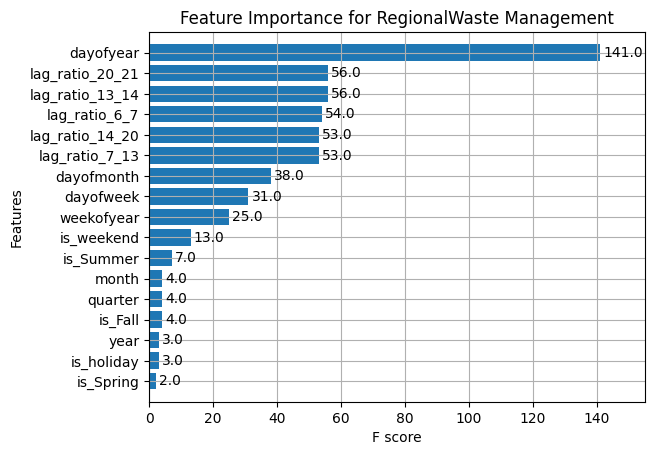

<Figure size 1000x800 with 0 Axes>

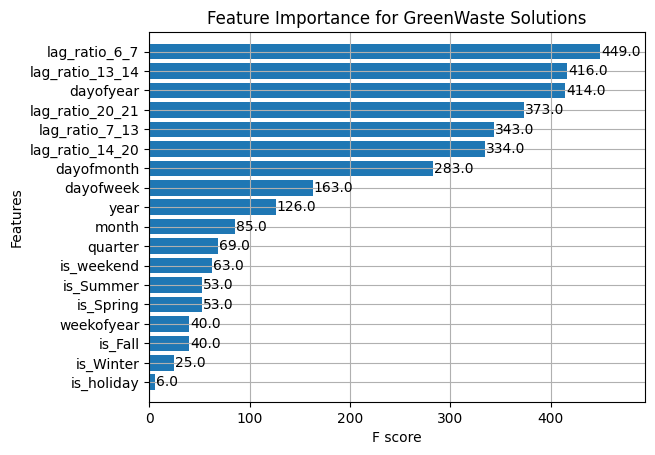

<Figure size 1000x800 with 0 Axes>

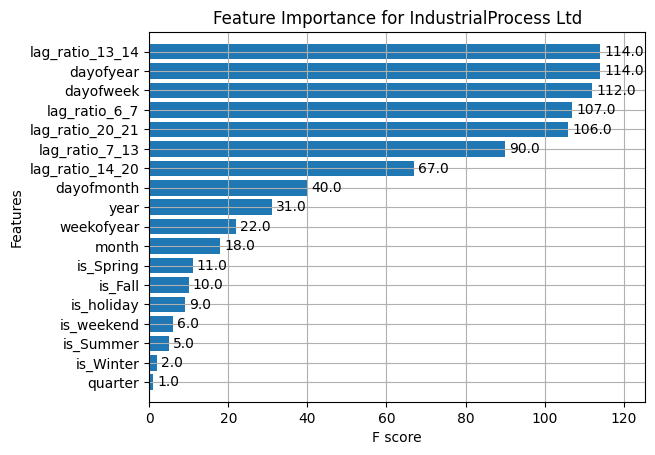

<Figure size 1000x800 with 0 Axes>

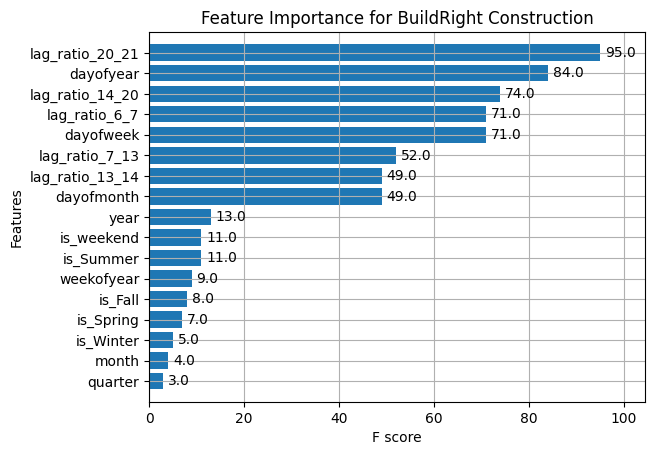

<Figure size 1000x800 with 0 Axes>

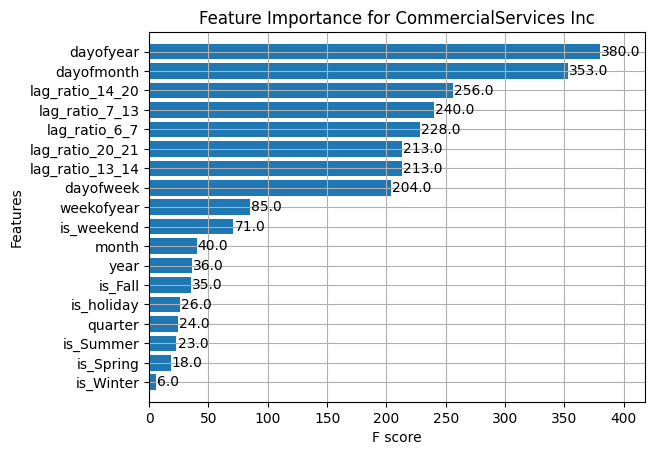

<Figure size 1000x800 with 0 Axes>

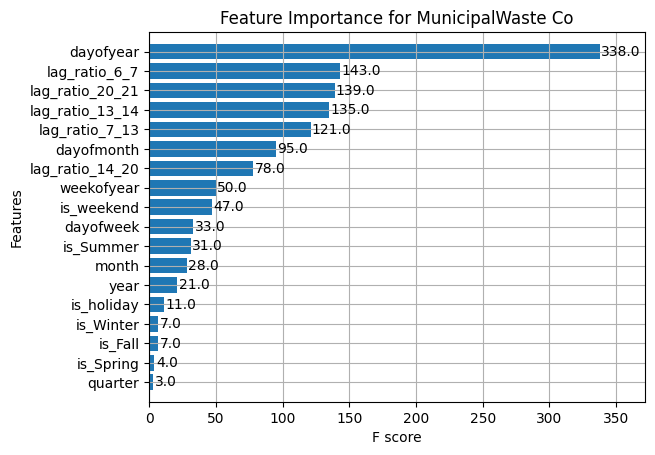

In [6]:
split_index = int(company_dfs["RegionalWaste Management"].shape[0] * 0.9)


company_quantity_preds = {}

for company, df in company_dfs.items():
    X = df.drop(columns=['quantity_tons'])
    y = df['quantity_tons']

    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    
    # Get the best parameters for this company
    best_params = XGBoostParams.get_company_params(company)
    
    # Create and train the model with best parameters
    best_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params  # Unpack the parameters
    )
    
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    company_quantity_preds[company] = y_pred

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(best_model, max_num_features=20, height=0.8)
    plt.title(f"Feature Importance for {company}")
    plt.show()

In [7]:
from sklearn.metrics import root_mean_squared_error

total_actual = np.sum(
    [company_dfs[company]['quantity_tons'].values[split_index:] for company in company_dfs],
    axis=0
)


total_predicted = np.sum(list(company_quantity_preds.values()), axis=0)

print(f"RMSE:{root_mean_squared_error(total_actual, total_predicted)}")

for company in unique_companies:
    actual = np.sum(
    [company_dfs[company]['quantity_tons'].values[split_index:]],
    axis=0)

    predicted = company_quantity_preds[company]

    print(f"RMSE for {company}: {root_mean_squared_error(actual, predicted)}")


RMSE:103.98792266845703
RMSE for RegionalWaste Management: 36.63507080078125
RMSE for GreenWaste Solutions: 15.24197769165039
RMSE for IndustrialProcess Ltd: 37.92293930053711
RMSE for BuildRight Construction: 23.95245933532715
RMSE for CommercialServices Inc: 26.47869110107422
RMSE for MunicipalWaste Co: 29.874223709106445


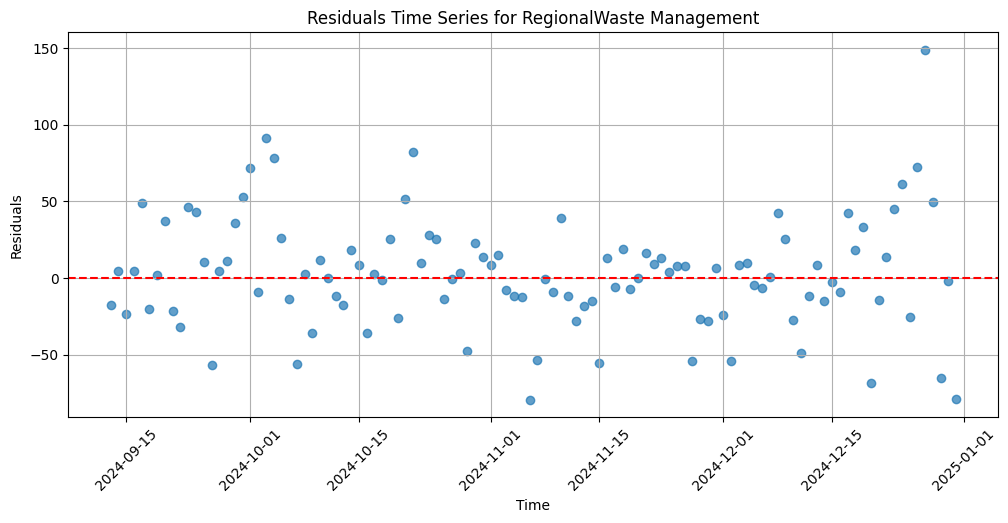

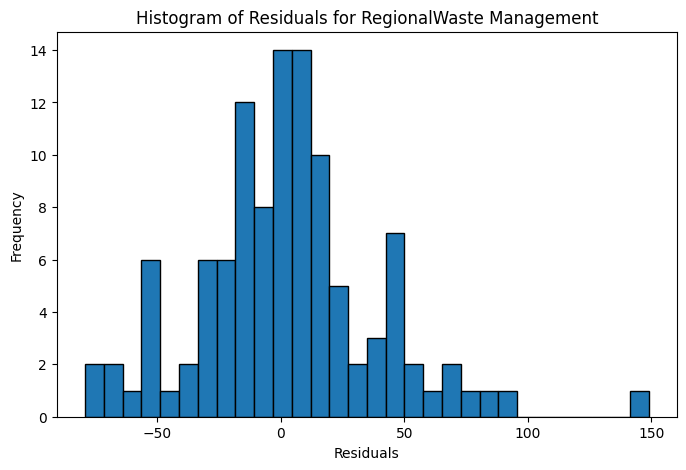

RegionalWaste Management - Mean Residual: 2.69
RegionalWaste Management - Standard Deviation: 36.54


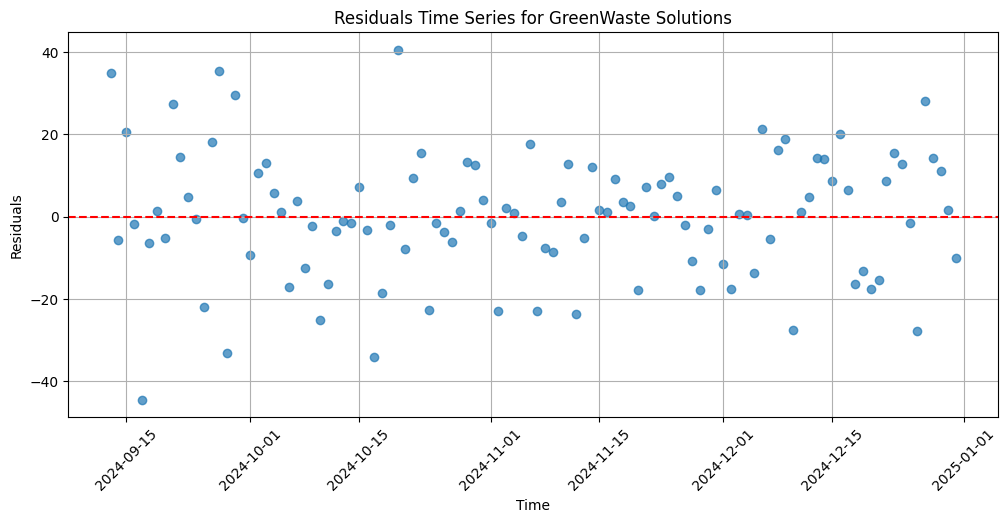

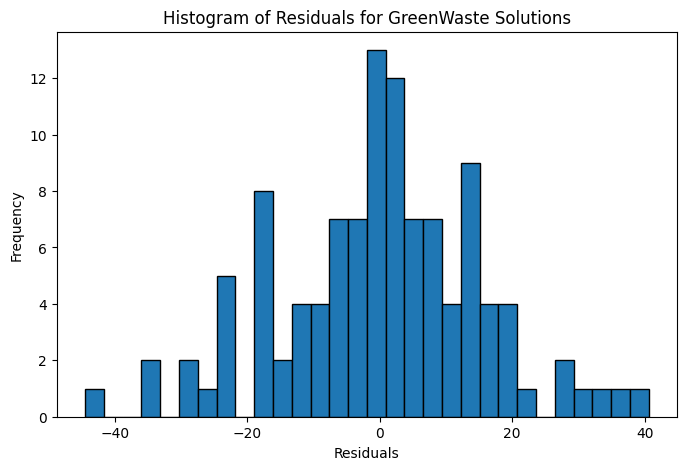

GreenWaste Solutions - Mean Residual: 0.13
GreenWaste Solutions - Standard Deviation: 15.24


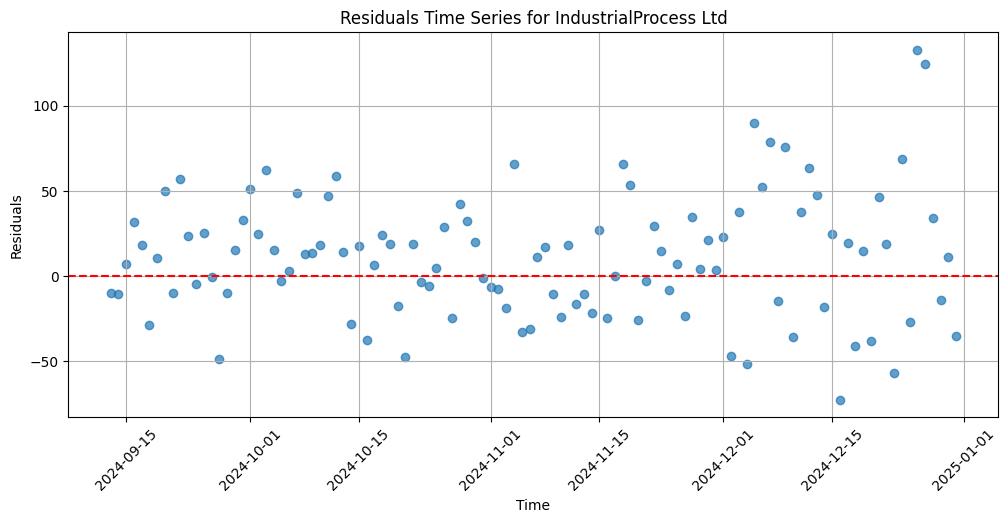

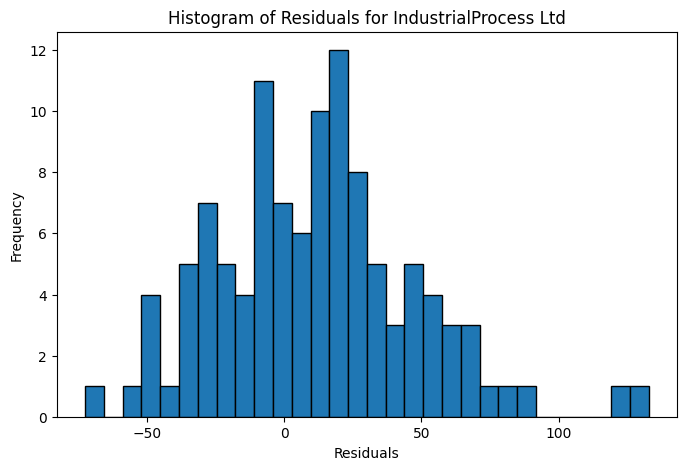

IndustrialProcess Ltd - Mean Residual: 11.14
IndustrialProcess Ltd - Standard Deviation: 36.25


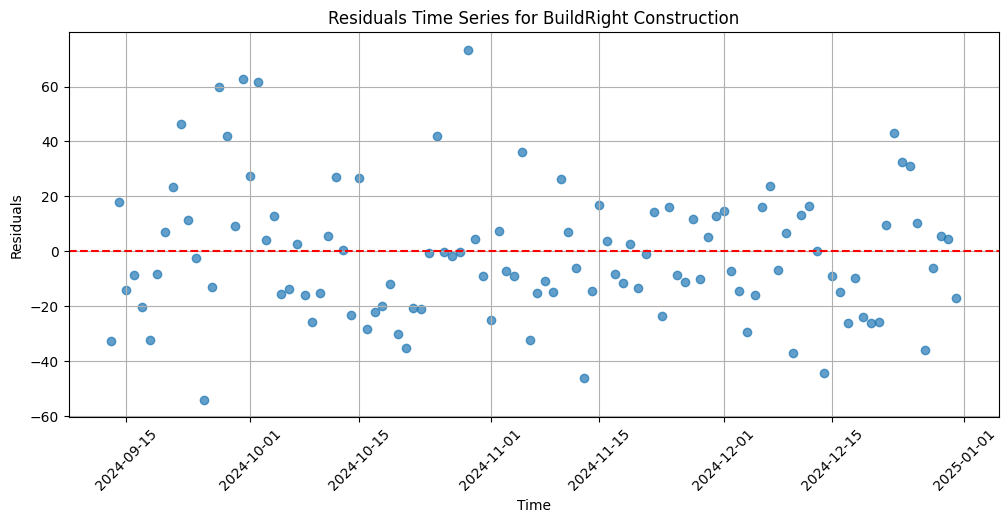

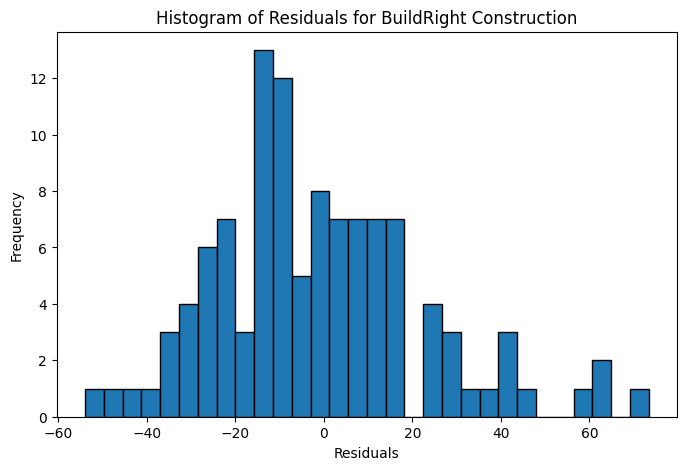

BuildRight Construction - Mean Residual: -1.41
BuildRight Construction - Standard Deviation: 23.91


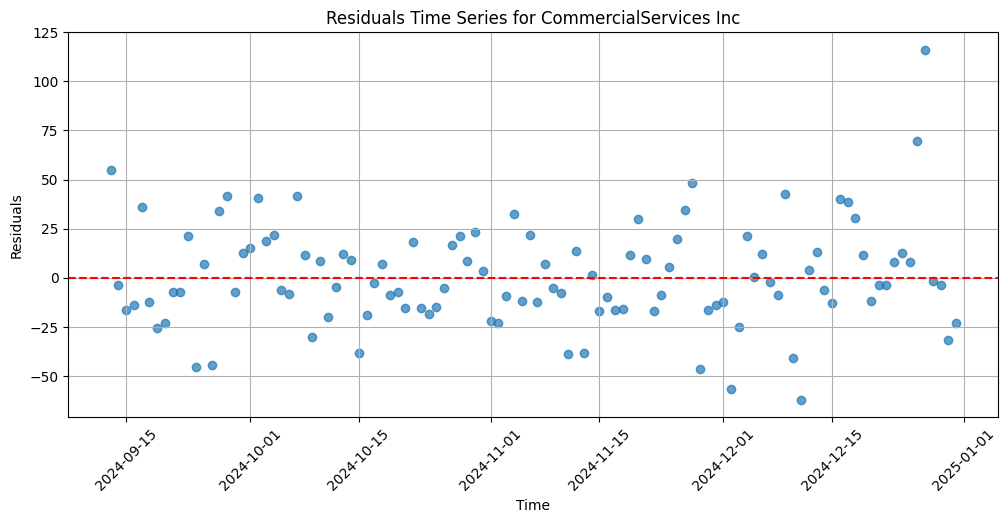

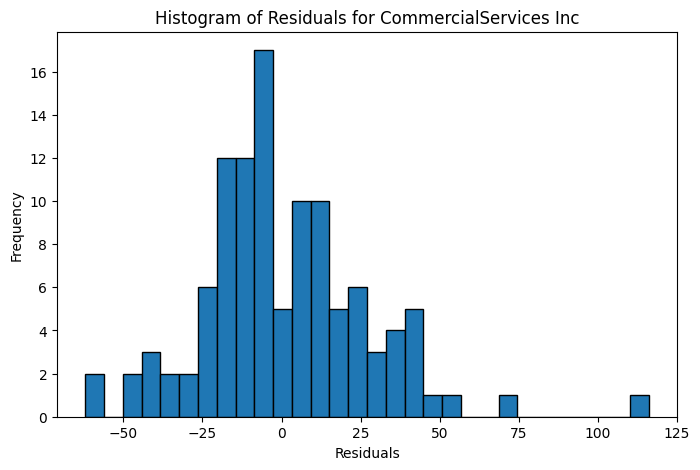

CommercialServices Inc - Mean Residual: 0.83
CommercialServices Inc - Standard Deviation: 26.47


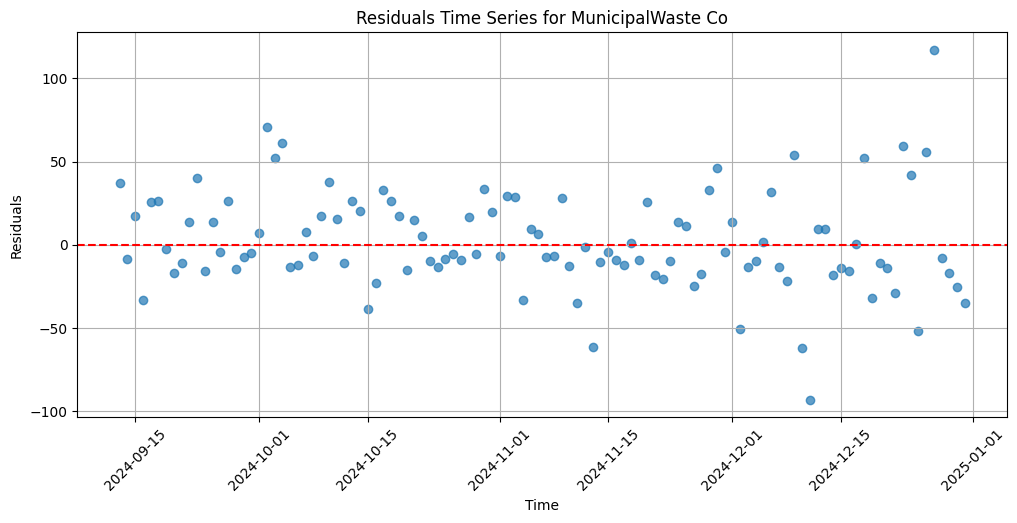

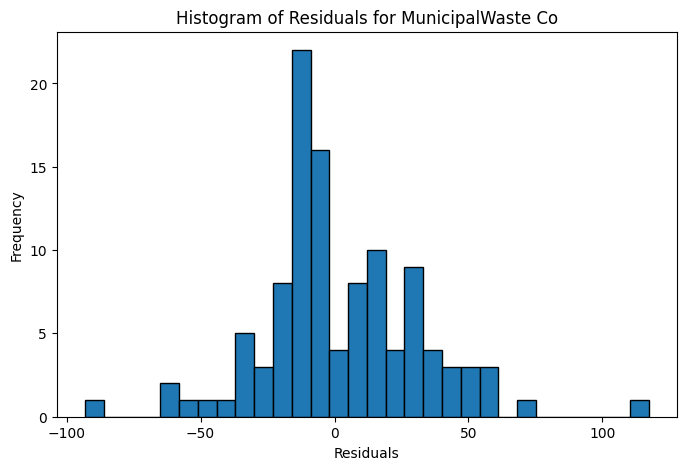

MunicipalWaste Co - Mean Residual: 2.13
MunicipalWaste Co - Standard Deviation: 29.80


In [8]:
for company in company_dfs:
    # Calculate total actual values for the company
    total_actual = company_dfs[company]['quantity_tons'].values[split_index:]

    # Calculate total predicted values for the company
    total_predicted = company_quantity_preds[company]  

    # Calculate residuals
    residuals = total_actual - total_predicted

    # Get the time index for the residuals
    time_index = company_dfs[company].index[split_index:]

    # Plot residuals as points over time
    plt.figure(figsize=(12, 5))
    plt.scatter(time_index, residuals, alpha=0.7)
    plt.axhline(y=0, color="red", linestyle="--")  # Zero-line for reference
    plt.xlabel("Time")
    plt.ylabel("Residuals")
    plt.title(f"Residuals Time Series for {company}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

    # Plot histogram of residuals
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30, edgecolor="black")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Residuals for {company}")
    plt.show()

    # Print mean and standard deviation of residuals
    print(f"{company} - Mean Residual: {residuals.mean():.2f}")
    print(f"{company} - Standard Deviation: {residuals.std():.2f}")